# Sydney Housing Price Prediction and Decision Support System

**Name: Dheisitha Kulunuguna**  
**Student ID: 225099575**

## Part 1: Problem Definition and Data Collection

**Problem:** A real estate agency wants a fast, evidence-based estimate of what a property will sell for. I treat this as regression: predict sale price from basic listing features,.

**Suburbs:** I chose three suburbs I would genuinely consider, representing very different markets: **Mosman** (premium lower North Shore, 8 km from the CBD), **Parramatta** (apartment-dominated second CBD, 24 km out) and **Penrith** (affordable outer west, 55 km out, mixed housing). I expect suburb to dominate price, with size and property type explaining differences within each.

**Data:** I manually recorded 176 sold properties from realestate.com.au (Mosman 69, Parramatta 51, Penrith 56): price, date, suburb, property type, bedrooms, bathrooms, parking, land size (0 for apartments, units, and studios), and approximate distances to the CBD and nearest transit stop (suburb-level assumptions).

**Quality and bias:** Collection was manual, so the sample is small. Land size is missing for 23 of 38 landed properties, some parking counts were blank, Parramatta has no houses, and sales span only about four months. Only advertised sales with public prices are included, and condition and views are not recorded, so conclusions apply to these three suburbs only.

In [1]:
import warnings; warnings.filterwarnings("ignore")
import numpy as np, pandas as pd, matplotlib.pyplot as plt, seaborn as sns, joblib
from sklearn.model_selection import KFold, cross_validate, cross_val_predict
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer, TransformedTargetRegressor
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from features import clean, add_features, CAT_COLS, NUM_COLS, FEATURES

sns.set_theme(style="whitegrid")
raw = pd.read_csv("data/sydney_sold_properties.csv")
print(raw.shape)
print(raw.suburb.value_counts())
raw.head()

(176, 10)
suburb
Mosman        69
Penrith       56
Parramatta    51
Name: count, dtype: int64


,sale_price,sale_date,suburb,property_type,bedrooms,bathrooms,parking,land_size,dist_cbd,dist_station
0,650000,2026-10-02,Mosman,Apartment,1.0,1,NaN,0,8,2.0
1,740000,2026-10-01,Mosman,Apartment,1.0,1,1.0,0,8,2.0
2,980000,2026-09-29,Mosman,Apartment,2.0,1,NaN,0,8,2.0
3,980000,2026-09-22,Mosman,Apartment,1.0,1,1.0,0,8,2.0
4,871000,2026-09-18,Mosman,Apartment,2.0,1,1.0,0,8,2.0


In [2]:
# Data quality checks, then cleaning (see features.clean for the rules)
print("Missing values per column:"); print(raw.isna().sum()[lambda s: s > 0])
print("Exact duplicate rows:", raw.duplicated().sum())

df = clean(raw)
landed = df.property_group != "Apartment"
print(f"\n{len(raw)} raw rows -> {len(df)} after removing exact duplicates")
print(f"Landed properties with no listed land size: {df.land_missing.sum()} of {landed.sum()}")

Missing values per column:
bedrooms      2
parking      23
land_size    24
dtype: int64
Exact duplicate rows: 2

176 raw rows -> 174 after removing exact duplicates
Landed properties with no listed land size: 23 of 38


**Cleaning:** I removed 2 exact duplicates (identical rows in both training and test folds would inflate scores), treated blank parking as zero and missing studio bedrooms as 0, and filled missing land size with the suburb median plus a `land_missing` flag. Rare property types (villa, duplex, retirement living) are grouped as Townhouse/Other, giving three groups: Apartment (including units and studios), House, and Townhouse/Other.

## Part 2: Data Understanding and Feature Engineering

            count     mean      std     min     25%      50%      75%       max
suburb                                                                         
Mosman         69  2394051  2249409  610000  930000  1450000  3200000  11650000
Parramatta     51   587353   120924  200000  543000   590000   670000    855000
Penrith        54   631407   190856  325000  497500   583000   785250   1060000


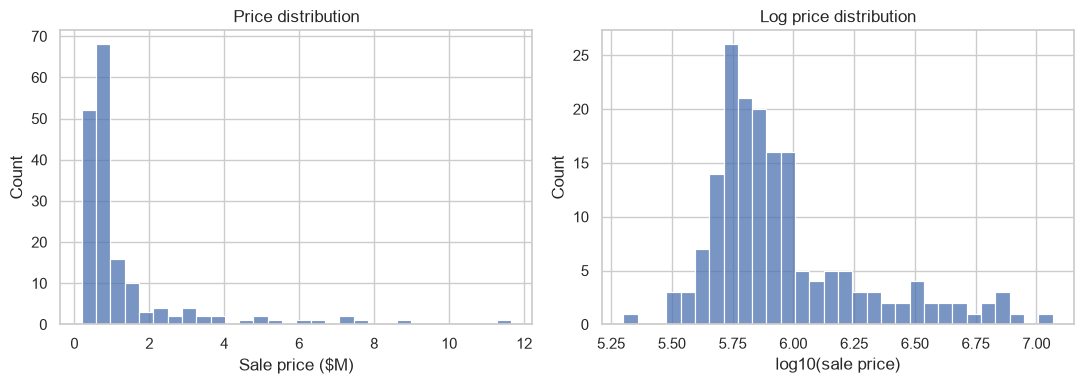

In [3]:
print(df.groupby("suburb").sale_price.describe().round(0).astype(int).to_string())

fig, ax = plt.subplots(1, 2, figsize=(11, 4))
sns.histplot(df.sale_price / 1e6, bins=30, ax=ax[0]); ax[0].set_xlabel("Sale price ($M)"); ax[0].set_title("Price distribution")
sns.histplot(np.log10(df.sale_price), bins=30, ax=ax[1]); ax[1].set_xlabel("log10(sale price)"); ax[1].set_title("Log price distribution")
plt.tight_layout(); plt.savefig("figures/01_price_distribution.png", dpi=150); plt.show()

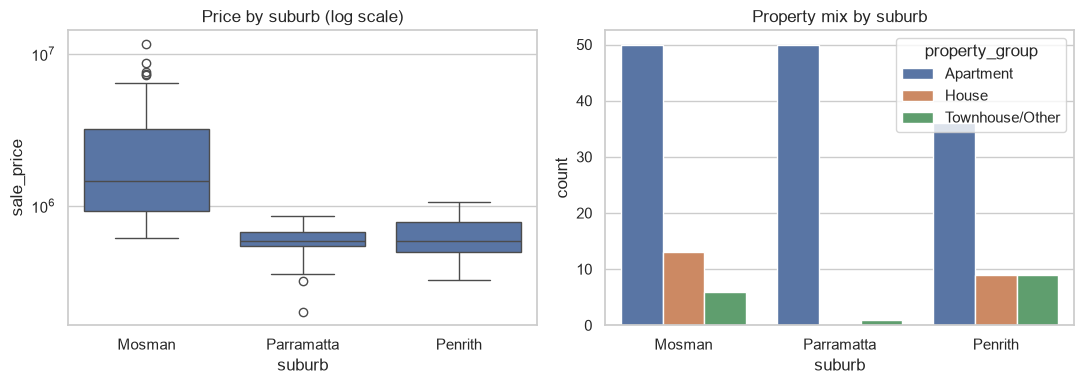

In [4]:
fig, ax = plt.subplots(1, 2, figsize=(11, 4))
sns.boxplot(data=df, x="suburb", y="sale_price", ax=ax[0]); ax[0].set_yscale("log"); ax[0].set_title("Price by suburb (log scale)")
sns.countplot(data=df, x="suburb", hue="property_group", ax=ax[1]); ax[1].set_title("Property mix by suburb")
plt.tight_layout(); plt.savefig("figures/02_suburb_comparison.png", dpi=150); plt.show()

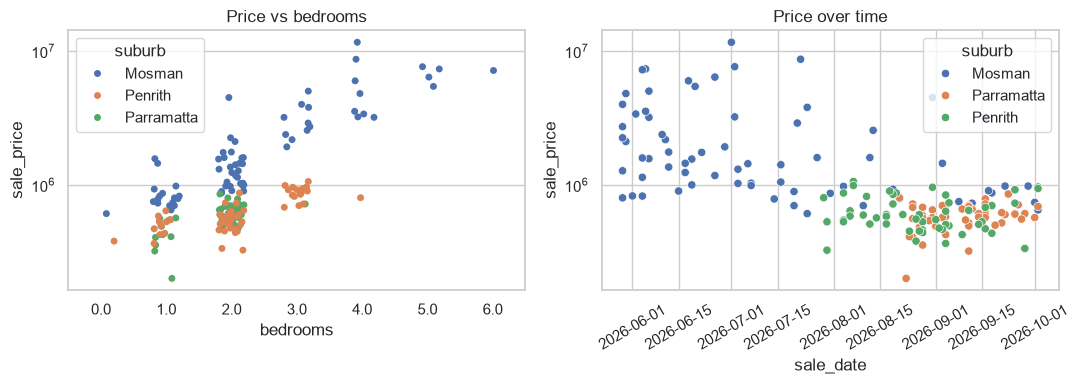

         sales  median_price  house_share
month                                    
2026-05      7     2250000.0         0.14
2026-06     26     1755000.0         0.27
2026-07     19     1310000.0         0.21
2026-08      7      975000.0         0.00
2026-09      8      942500.0         0.12
2026-10      2      695000.0         0.00


In [5]:
fig, ax = plt.subplots(1, 2, figsize=(11, 4))
sns.stripplot(data=df, x="bedrooms", y="sale_price", hue="suburb", ax=ax[0], jitter=0.2)
ax[0].set_yscale("log"); ax[0].set_title("Price vs bedrooms")
d = df.assign(sale_date=pd.to_datetime(df.sale_date))
sns.scatterplot(data=d, x="sale_date", y="sale_price", hue="suburb", ax=ax[1])
ax[1].set_yscale("log"); ax[1].set_title("Price over time"); ax[1].tick_params(axis="x", rotation=30)
plt.tight_layout(); plt.savefig("figures/03_bedrooms_and_time.png", dpi=150); plt.show()

# Is the apparent fall in Mosman prices a market trend or a change in mix?
mos = d[d.suburb == "Mosman"].assign(month=lambda x: x.sale_date.dt.to_period("M"))
print(mos.groupby("month").agg(sales=("sale_price", "size"), median_price=("sale_price", "median"),
      house_share=("property_group", lambda s: round((s == "House").mean(), 2))))

In [6]:
# Outliers: IQR rule within each suburb
for s, g in df.groupby("suburb"):
    q1, q3 = g.sale_price.quantile([.25, .75]); hi = q3 + 1.5 * (q3 - q1); lo = q1 - 1.5 * (q3 - q1)
    out = g[(g.sale_price > hi) | (g.sale_price < lo)]
    print(s, "outliers:", len(out), "| prices ($):", sorted(out.sale_price.tolist()))

Mosman outliers: 5 | prices ($): [7260000, 7360000, 7650000, 8700000, 11650000]
Parramatta outliers: 2 | prices ($): [200000, 320000]
Penrith outliers: 0 | prices ($): []


**Findings:** Prices are strongly right-skewed (median about `$715k`, maximum `$11.65M`), driven by Mosman, whose median (`$1.45M`) is more than double Parramatta (`$590k`) and Penrith (`$583k`); Mosman houses (median `$5.45M`) sell for about five times Mosman apartments (`$1.04M`). The outliers (Mosman houses above `$7M`, a `$200k` Parramatta studio) are genuine sales, so I kept them and model log price to limit their pull. Mosman prices appear to fall over time, but June had more houses (27% of sales) than later months (12% or less from August), so this is likely a change in mix, not a market trend. I cannot separate the two with four months of data, so sale date is not used as a feature.

**Expected top three drivers (stated before feature engineering).** (1) **Suburb**, as the markets differ by more than a factor of two; (2) **property type**, as houses carry land value; (3) **bedrooms**, as the main proxy for size.

In [7]:
df = add_features(df)
print(df[["bedrooms", "bathrooms", "total_rooms", "land_size", "log_land", "is_landed", "has_parking", "land_missing"]].head())

print("\nDistinct dist_cbd / dist_station values per suburb:")
print(df.groupby("suburb")[["dist_cbd", "dist_station"]].nunique())

num = ["bedrooms", "bathrooms", "parking", "land_size", "total_rooms", "is_landed", "has_parking"]
print("\nSpearman correlation with sale price:")
print(df[["sale_price"] + num].corr(method="spearman")["sale_price"].drop("sale_price").sort_values(ascending=False).round(2))

   bedrooms  bathrooms  total_rooms  land_size  log_land  is_landed  \
0       1.0          1          2.0        0.0       0.0          0   
1       1.0          1          2.0        0.0       0.0          0   
2       2.0          1          3.0        0.0       0.0          0   
3       1.0          1          2.0        0.0       0.0          0   
4       2.0          1          3.0        0.0       0.0          0   

   has_parking  land_missing  
0            0             0  
1            1             0  
2            0             0  
3            1             0  
4            1             0  

Distinct dist_cbd / dist_station values per suburb:
            dist_cbd  dist_station
suburb                            
Mosman             1             1
Parramatta         1             1
Penrith            1             1

Spearman correlation with sale price:
bedrooms       0.56
total_rooms    0.51
is_landed      0.49
land_size      0.48
parking        0.41
bathrooms      0.40


**Feature engineering:** I added `total_rooms`, `is_landed`, `has_parking`, `log_land` (land size is skewed), and `land_missing`. The distance columns have one value per suburb, so they duplicate suburb and are excluded. Bedrooms (0.56) and total rooms (0.51) have the strongest numeric correlations with price, followed by landed status (0.49), consistent with my expectation. The engineered features mostly re-express size and property type, refining rather than overturning my initial view.

## Part 3: Model Development and Evaluation

**Models and expectation (stated before training):** **Ridge regression** is a regularized linear baseline: robust with small data, but unable to capture interactions such as suburb × property type. **Random Forest** averages many trees, capturing interactions, but can overfit small samples. **Gradient Boosting** corrects errors sequentially and is often the most accurate on tabular data, but is the most sensitive to small samples. Since price depends on suburb non-linearly, **I expect Gradient Boosting to perform best, then Random Forest, then Ridge.** Models are trained on log price and predictions converted back to dollars, evaluated with 5-fold shuffled cross-validation (MAE, RMSE, R², MAPE).

In [8]:
def make_model(estimator):
    pre = ColumnTransformer([("cat", OneHotEncoder(handle_unknown="ignore"), CAT_COLS), ("num", StandardScaler(), NUM_COLS)])
    return TransformedTargetRegressor(Pipeline([("pre", pre), ("model", estimator)]), func=np.log, inverse_func=np.exp)

models = {
    "Ridge": Ridge(alpha=1.0),
    "Random Forest": RandomForestRegressor(n_estimators=300, min_samples_leaf=2, random_state=42),
    "Gradient Boosting": GradientBoostingRegressor(n_estimators=200, learning_rate=0.05, max_depth=3, random_state=42),
}
X, y = df[FEATURES], df.sale_price
cv = KFold(n_splits=5, shuffle=True, random_state=42)
scoring = {"mae": "neg_mean_absolute_error", "rmse": "neg_root_mean_squared_error",
           "r2": "r2", "mape": "neg_mean_absolute_percentage_error"}

rows = {}
for name, est in models.items():
    r = cross_validate(make_model(est), X, y, cv=cv, scoring=scoring, return_train_score=True)
    rows[name] = {"CV MAE ($)": -r["test_mae"].mean(), "CV RMSE ($)": -r["test_rmse"].mean(),
                  "CV R2": r["test_r2"].mean(), "CV MAPE (%)": -r["test_mape"].mean() * 100,
                  "Train R2": r["train_r2"].mean()}
results = pd.DataFrame(rows).T
results.round({"CV MAE ($)": 0, "CV RMSE ($)": 0, "CV R2": 3, "CV MAPE (%)": 1, "Train R2": 3})

,CV MAE ($),CV RMSE ($),CV R2,CV MAPE (%),Train R2
Ridge,318528.0,697784.0,0.801,19.3,0.840
Random Forest,319455.0,768220.0,0.746,18.3,0.899
Gradient Boosting,381727.0,908494.0,0.652,19.4,0.980


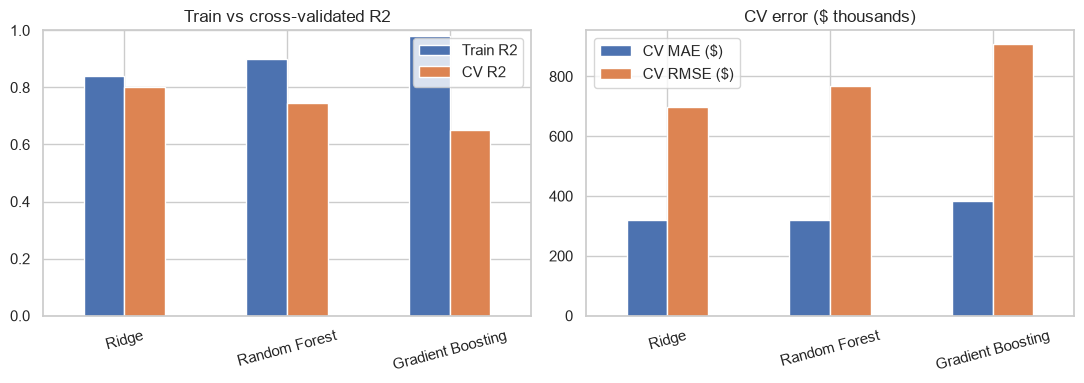

cat__suburb_Mosman     0.400
num__total_rooms       0.232
num__bedrooms          0.156
num__parking           0.098
num__bathrooms         0.064
cat__suburb_Penrith    0.011
dtype: float64


In [9]:
fig, ax = plt.subplots(1, 2, figsize=(11, 4))
results[["Train R2", "CV R2"]].plot.bar(ax=ax[0], rot=15); ax[0].set_title("Train vs cross-validated R2"); ax[0].set_ylim(0, 1)
results[["CV MAE ($)", "CV RMSE ($)"]].div(1e3).plot.bar(ax=ax[1], rot=15); ax[1].set_title("CV error ($ thousands)")
plt.tight_layout(); plt.savefig("figures/04_model_comparison.png", dpi=150); plt.show()

# Which features does a forest rely on? (fit on all data, for interpretation only)
rf = make_model(models["Random Forest"]).fit(X, y).regressor_
names = rf.named_steps["pre"].get_feature_names_out()
imp = pd.Series(rf.named_steps["model"].feature_importances_, index=names).sort_values(ascending=False)
print(imp.head(6).round(3))

**Evaluation:** Ridge had the best cross-validated MAE (almost $319k, just under Random Forest), RMSE, and R² (about 0.80); Random Forest had the lowest mean percentage error (18.3% vs 19.3%); Gradient Boosting was clearly worst (R² about 0.65). The train-versus-CV gap explains why. Ridge fits modestly (0.84 vs 0.80), so its remaining error reflects missing information rather than model flexibility. Random Forest overfits moderately (0.90 vs 0.75) and Gradient Boosting severely (0.98 vs 0.65), memorizing individual sales, especially rare expensive Mosman houses, because there are only 174 properties.

**Expectation vs result:** My prediction was not supported. Gradient Boosting finished last and the simplest model won, so added complexity only helps with enough data. Feature importance did support my feature expectations (Mosman and size dominate), though property type ranked lower than expected because bedrooms, bathrooms, and parking already capture much of the same information.

**Recommendation:** I recommend **Ridge regression**. Best on three of four validation metrics, smallest overfitting gap, and simple, stable, and fast to deploy. Random Forest is a close second.

## Part 4: Investigating Prediction Failures

In [10]:
best_name = results["CV RMSE ($)"].idxmin()
print("Best model by CV RMSE:", best_name)
df["pred"] = cross_val_predict(make_model(models[best_name]), X, y, cv=cv)
df["error"] = df.pred - df.sale_price
df["abs_error"] = df.error.abs()
df["error_pct"] = df.error / df.sale_price * 100

top5 = df.sort_values("abs_error", ascending=False).head(5)
cols = ["suburb", "property_type", "bedrooms", "bathrooms", "parking", "land_size", "land_missing",
        "sale_price", "pred", "error", "error_pct"]
top5[cols].round(0).astype({"sale_price": int, "pred": int, "error": int})

Best model by CV RMSE: Ridge


,suburb,property_type,bedrooms,bathrooms,parking,land_size,land_missing,sale_price,pred,error,error_pct
35,Mosman,House,4.0,4,2.0,542.0,1,11650000,5809174,-5840826,-50.0
33,Mosman,House,5.0,2,2.0,490.0,0,7650000,3945320,-3704680,-48.0
21,Mosman,House,4.0,3,2.0,542.0,1,8700000,5377711,-3322289,-38.0
56,Mosman,House,6.0,4,3.0,879.0,0,7260000,9974492,2714492,37.0
10,Mosman,Apartment,2.0,2,2.0,0.0,0,4500000,1908446,-2591554,-58.0


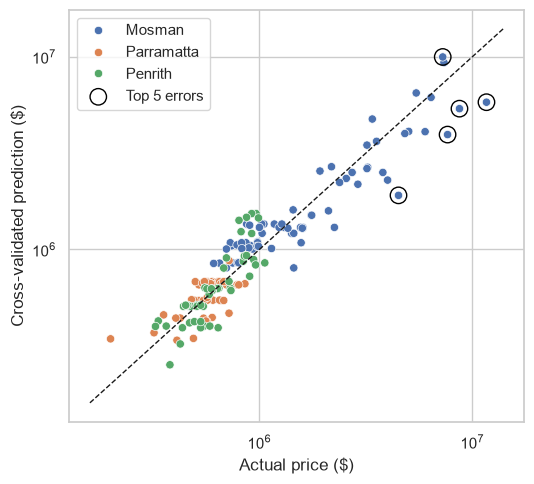

Median absolute % error by property group:
property_group
Apartment          14.5
House              19.5
Townhouse/Other    20.6
Name: error_pct, dtype: float64

By whether land size was missing:
land_missing
0    14.7
1    19.0
Name: error_pct, dtype: float64


In [11]:
fig, ax = plt.subplots(figsize=(5.5, 5))
sns.scatterplot(data=df, x="sale_price", y="pred", hue="suburb", ax=ax)
ax.scatter(top5.sale_price, top5.pred, s=140, facecolors="none", edgecolors="black", label="Top 5 errors")
lim = [df.sale_price.min() * 0.8, df.sale_price.max() * 1.2]
ax.plot(lim, lim, "k--", lw=1); ax.set_xscale("log"); ax.set_yscale("log")
ax.set_xlabel("Actual price ($)"); ax.set_ylabel("Cross-validated prediction ($)"); ax.legend()
plt.tight_layout(); plt.savefig("figures/05_actual_vs_predicted.png", dpi=150); plt.show()

print("Median absolute % error by property group:"); print(df.groupby("property_group").error_pct.apply(lambda s: s.abs().median()).round(1))
print("\nBy whether land size was missing:"); print(df.groupby("land_missing").error_pct.apply(lambda s: s.abs().median()).round(1))

**Five largest errors:** Four are Mosman houses priced `$7.3M` to `$11.65M`; the fifth is a `$4.5M` two-bedroom Mosman apartment predicted at about `$1.9M`. Four were under-predicted, some by about half, and one (a six-bedroom, 879 m² house) was over-predicted by `$2.7M`. Two houses had imputed land size. The likely causes are information the model never saw (views, waterfront, street, condition, exact land area); a `$4.5M` two-bedroom apartment is probably a premium harbour-view property that bedrooms and parking cannot describe. The luxury segment is also thin and dispersed, and a linear model on log price shrinks extremes toward the average.

**Limitations and caution:** Predictions should be treated cautiously for premium Mosman houses, unusual apartments, unlisted land size, and any Parramatta house (none in the data). Some properties are inherently harder: median percentage error is about 14.5% for apartments but 19-21% for houses and townhouses, and 19% when land size was missing against 14.7% when known. Per-property land area, views, renovation status, distance to station, and the agent description text would likely help.

## Part 5: Final Deployment and Reflection

In [12]:
# Train the recommended model on all data and save it for the app
final = make_model(models[best_name]).fit(X, y)
typical_error = float((df.error_pct.abs() / 100).median())
joblib.dump({"model": final, "name": best_name, "typical_pct_error": typical_error}, "model.joblib")
print(f"Saved {best_name} to model.joblib | typical cross-validated error: {typical_error:.1%}")

Saved Ridge to model.joblib | typical cross-validated error: 16.0%


**Application:** I used **Streamlit**, which turns a short Python script into a web page with no front-end code. `app.py` loads the saved Ridge pipeline (`model.joblib`), takes suburb, property type, bedrooms, bathrooms, parking, and land size from a form, applies the same `add_features` function as training, and shows the predicted price with an indicative range based on the typical (median) cross-validated error of about 16%. It warns for poorly handled cases such as Parramatta houses and premium Mosman houses.

**Build, run, and use:** Refer to the **README.md file** included in this repository.

**Live app:** [Sydney Housing Prediction System](https://s225099575-sydney-housing-prediction-decision-suppor-app-scrkz5.streamlit.app)

**GitHub:** [Prediction System Github Repository](https://github.com/s225099575/Sydney-Housing-Prediction-Decision-Support-System)

**Screenshots:**

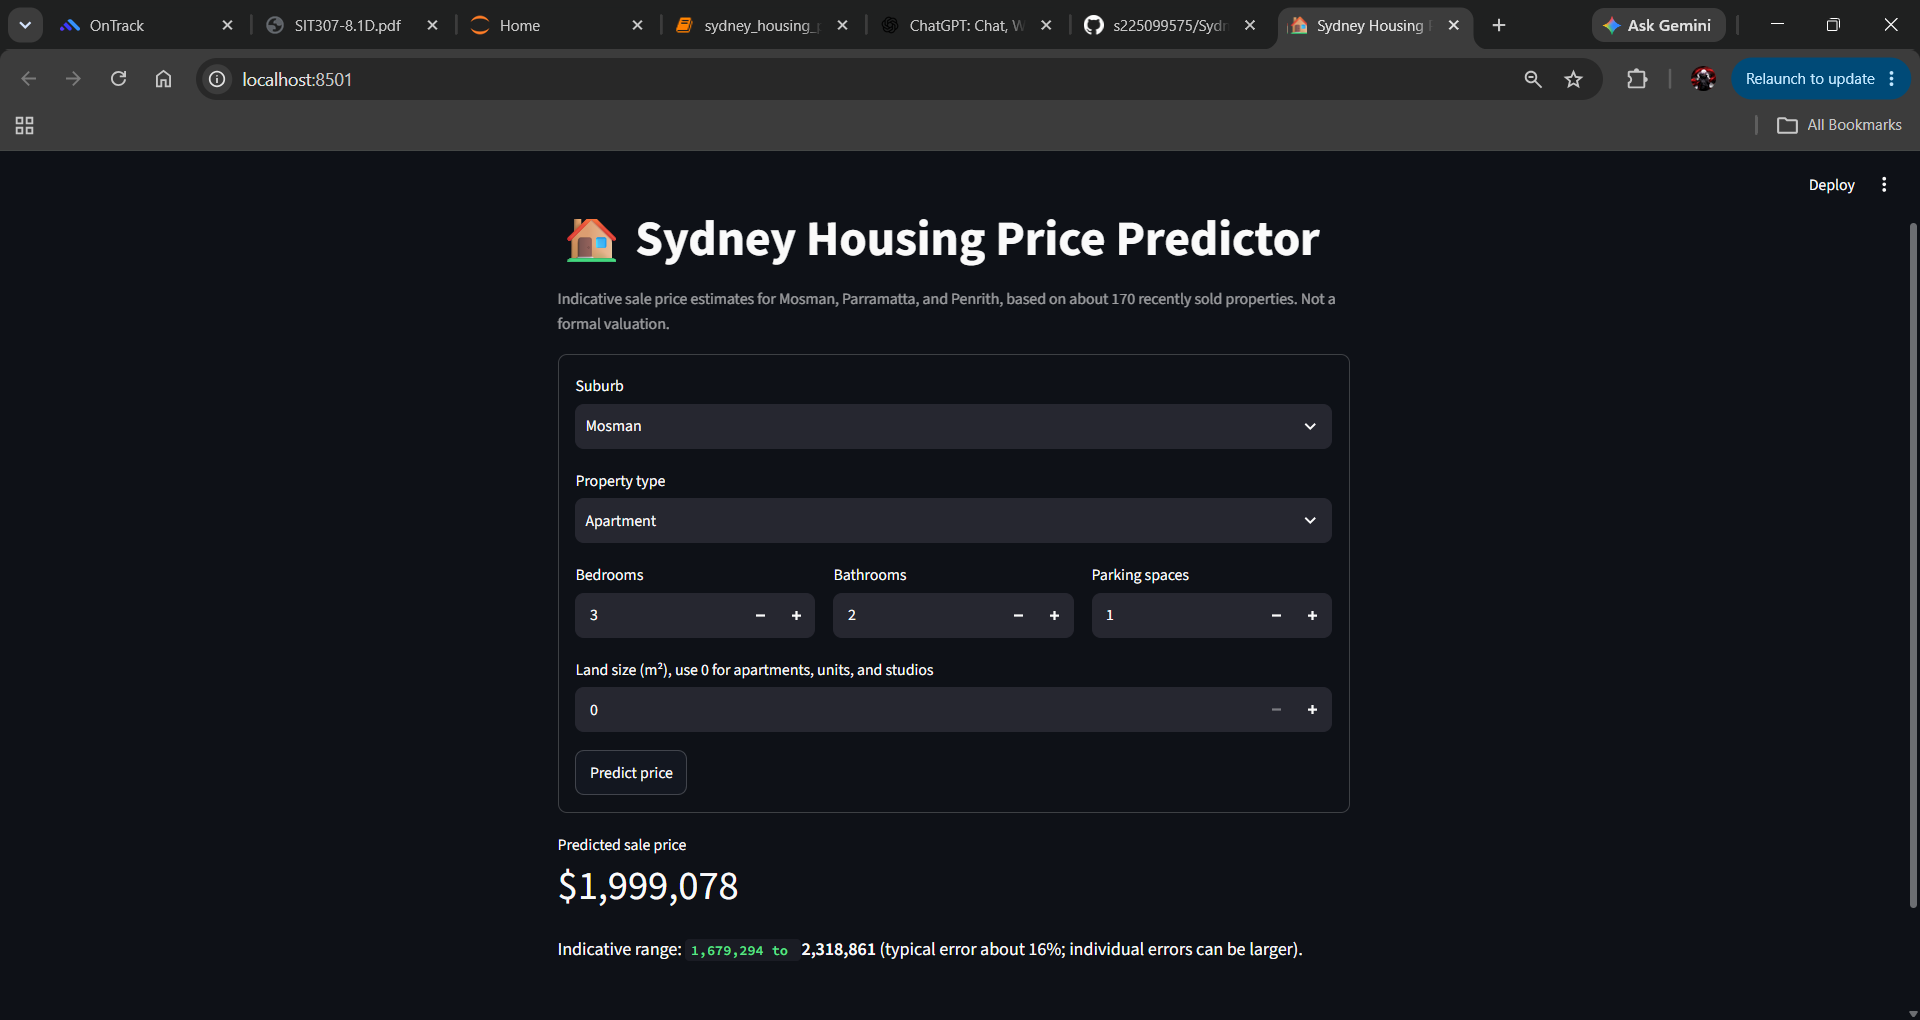

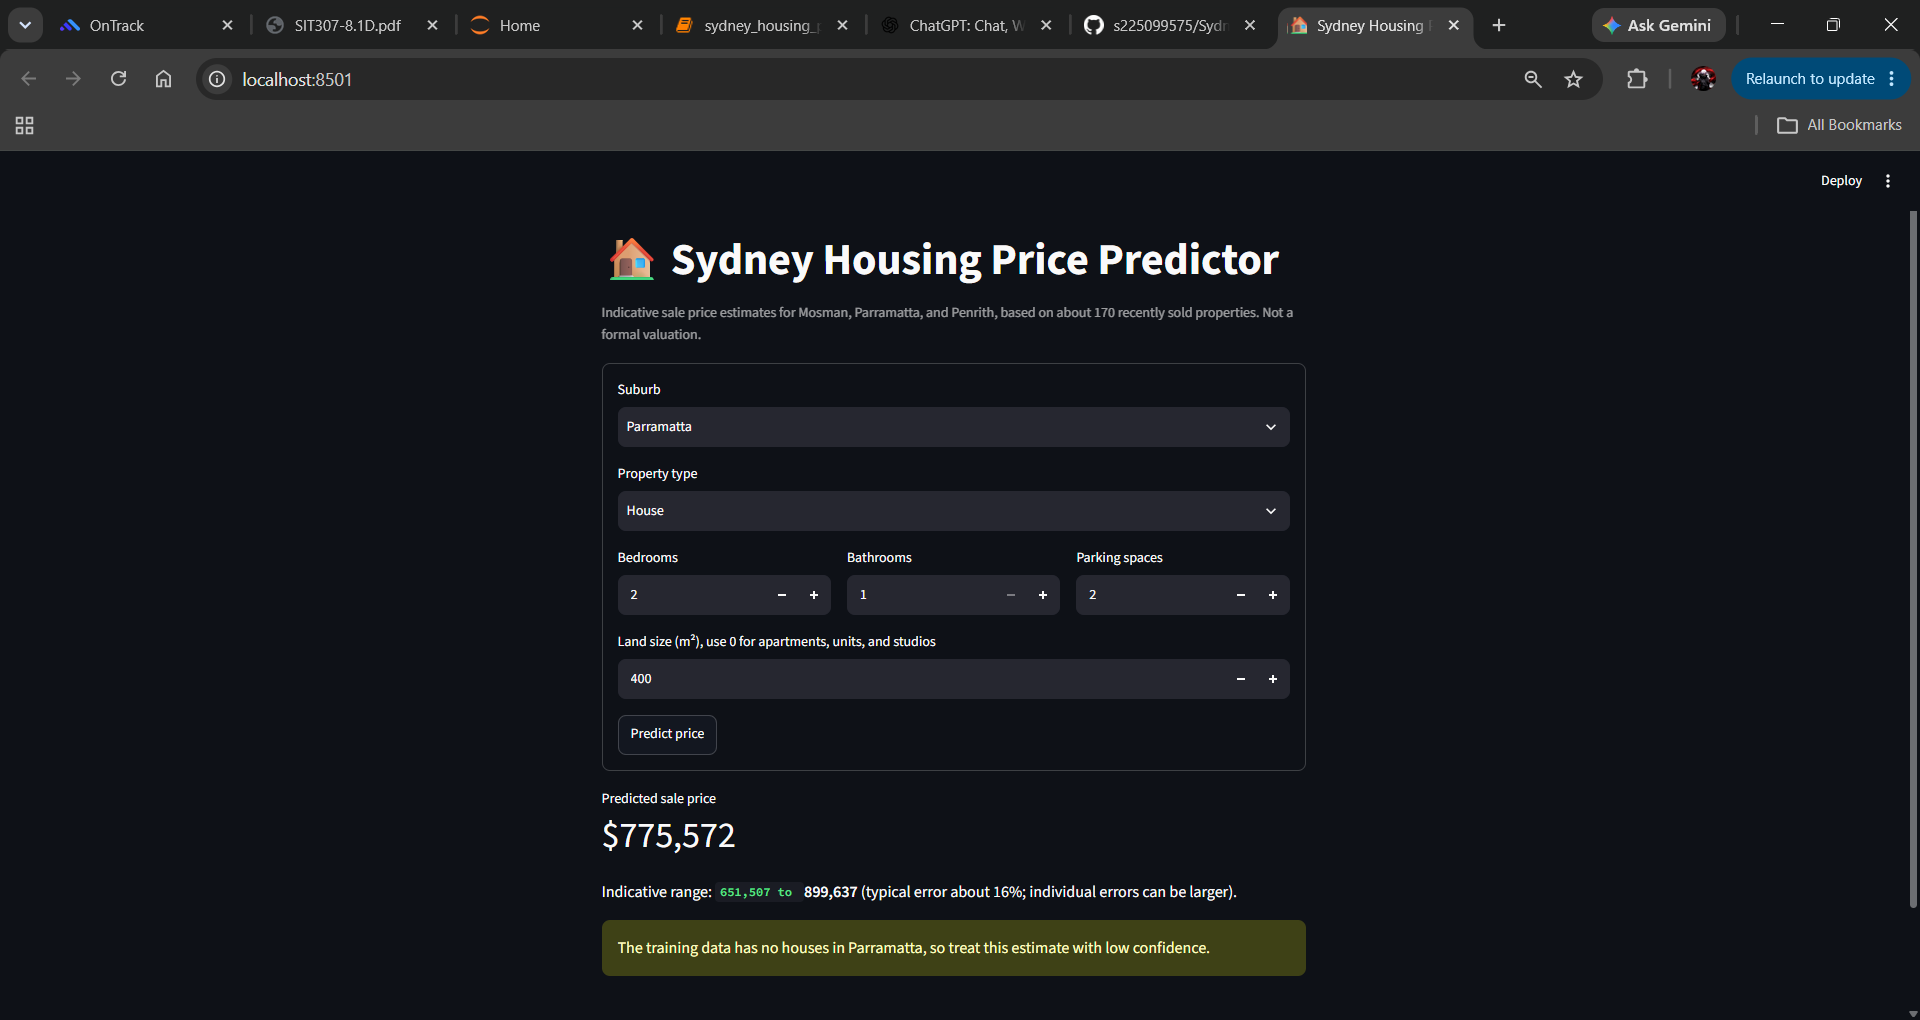

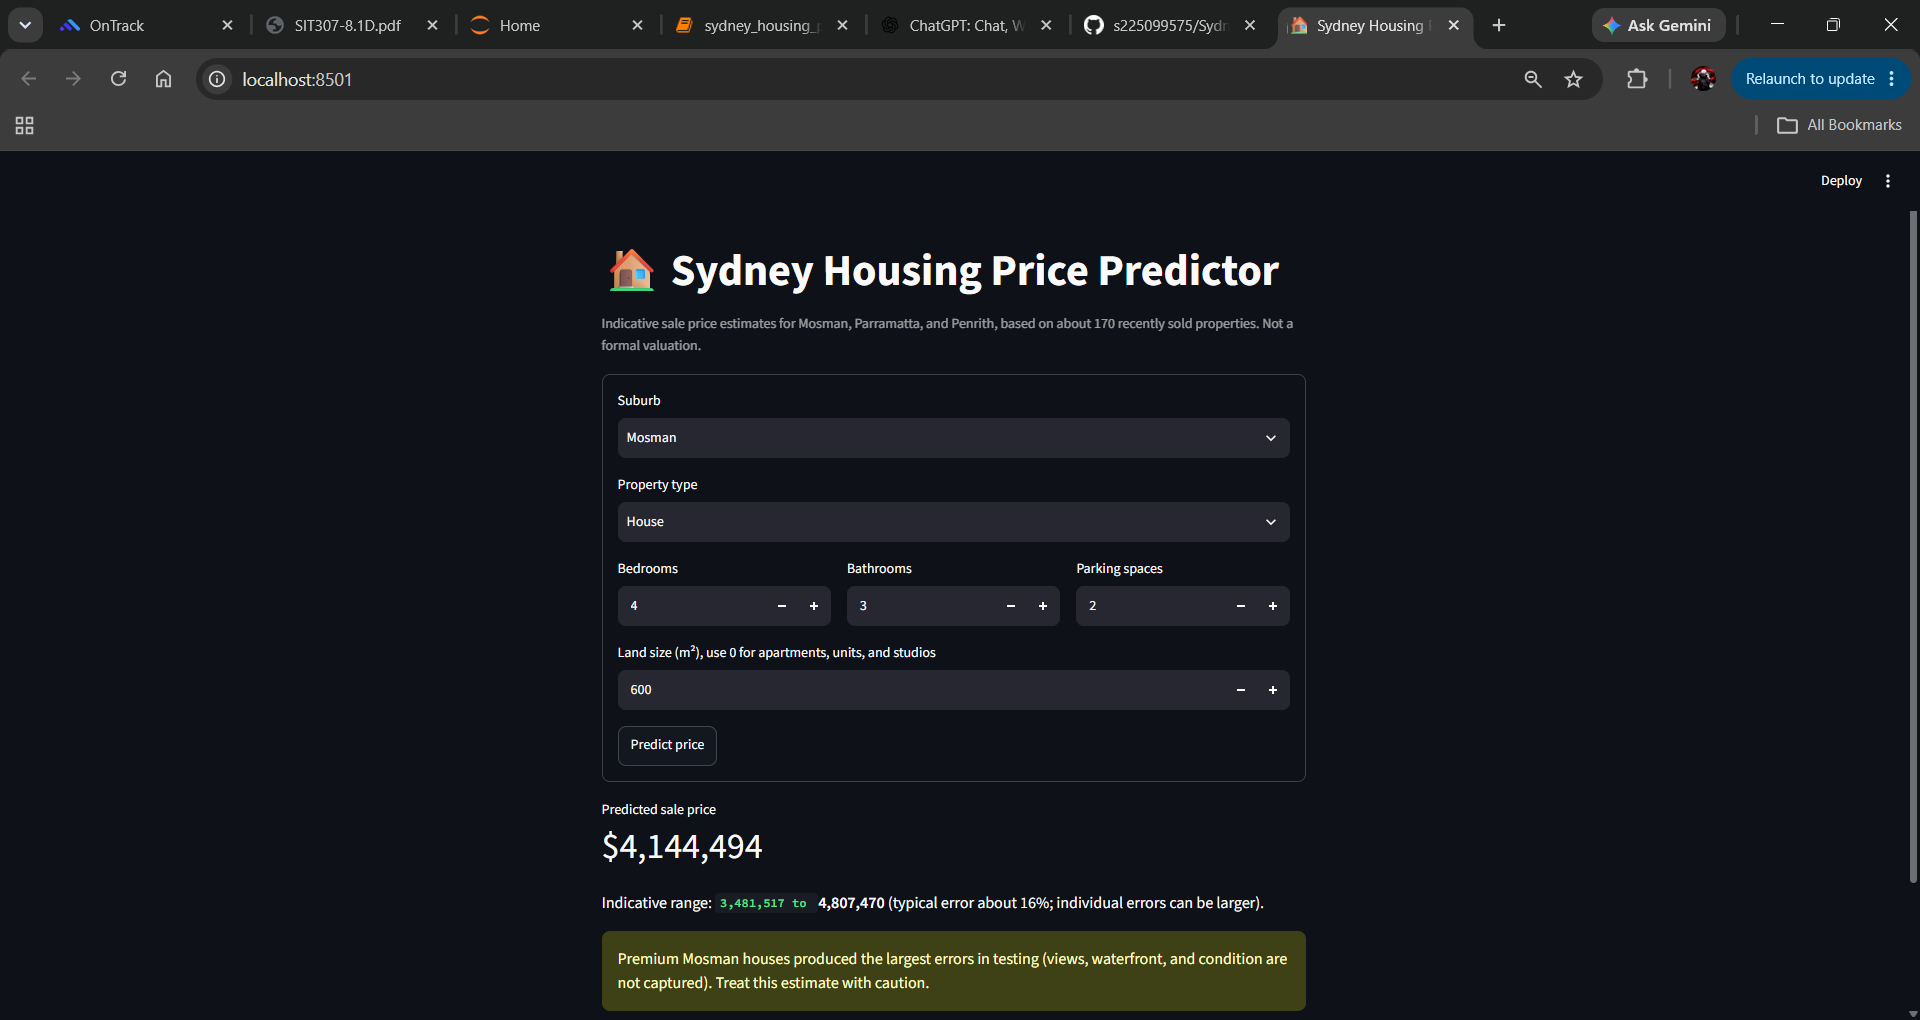

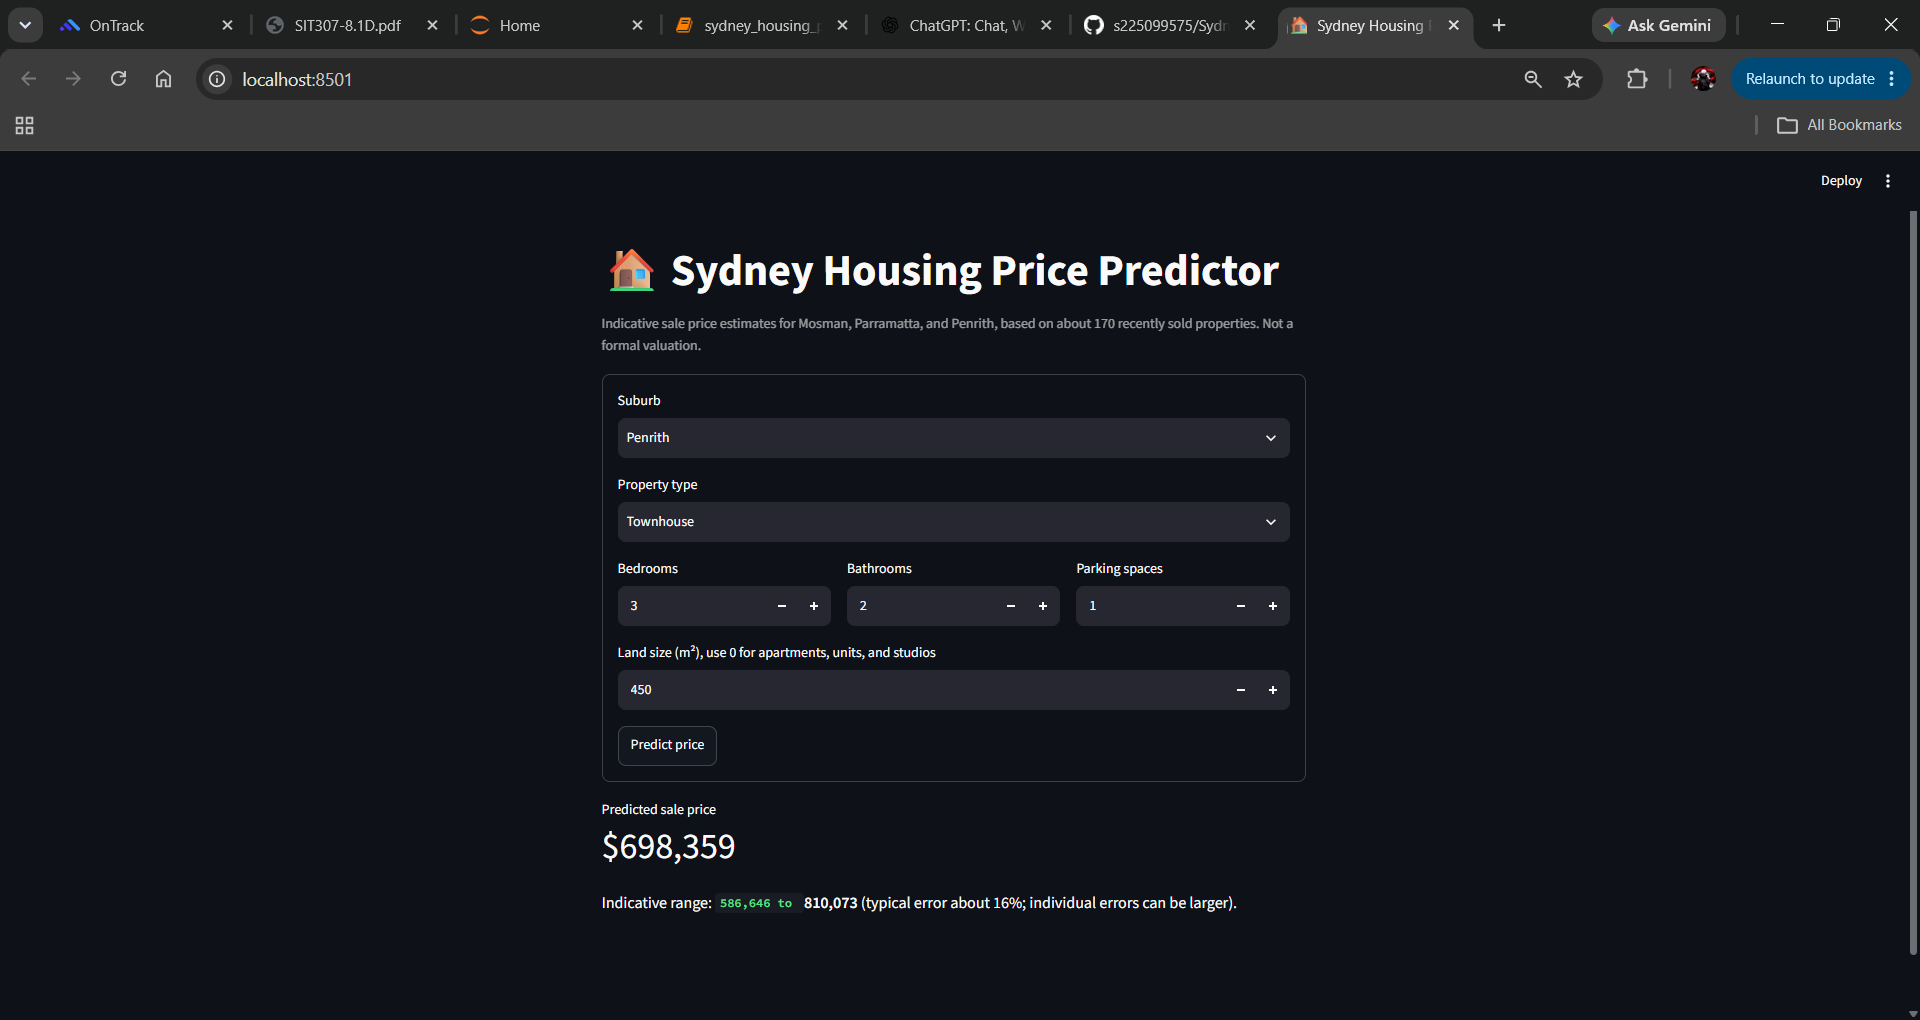

## Reflection

**Lessons and challenges:** Data quality mattered more than model choice. The simplest model won because 174 manually collected sales cannot support flexible models, and the largest errors came from information never recorded. Manual collection was slow and left gaps (land size missing for 60% of landed properties), and each preprocessing choice affects results, so I documented them. The distance features were redundant because I could only assign one value per suburb, a reminder to check that a variable adds information.

**Performance vs deployment:** Ridge is faster, easier to explain to a non-technical agent and safer to deploy than flexible models, and the app shows a range rather than a single number to reflect real uncertainty.

**Bias and limitations:** The data covers three suburbs, advertised sales only, and about four months, so the model will not generalize to other areas or market conditions. Because price is so tied to suburb, the model largely reproduces existing area-level price gaps, which could reinforce them if used uncritically; it should support, not replace, professional valuation. With more resources I would collect more sales over a longer period, add per-property distances, views, condition, and land area, use the description text, and tune models with nested cross-validation.

## References

**Streamlit Documentation:** [docs.streamlit.io](https://docs.streamlit.io/)  
**Property Sales Data:** [realestate.com.au](https://www.realestate.com.au/)

---

#### Generative AI Acknowledgement
Generative AI was used as a supplementary tool during the development of this notebook to assist with structuring the analysis, Python code syntax and debugging, and improving the clarity and flow of code and written explanations. It was also used as a second opinion when interpreting analytical results.

All property data were collected manually from realestate.com.au. I reviewed and ran all code and take responsibility for the accuracy of the code, results, analyses, interpretations, and conclusions presented in this notebook. All final content was reviewed and verified by the author.